# SIPLab Decision Making Research/Computational Skills Assessment
Name: Daniel Achacon

# Creating a Decision Making Task

To study how humans make decisions, experimentalists distil the question they want to answer into a toy task. In this exercise, we will work on studying _effort based decision making_ a paradigm that examines motivation of a person by determining the amount of effort a person is willing to expend to receive a reward.

The following code uses a Python library called [Psychopy](https://www.psychopy.org/api/index.html#api) to create an experiment. The great feature of this library is the ability to get precise timings of the various screens displayed - a key feature in modelling decision making as you will later see.

For now, run the following code a few times and see if you can choose your preferred option, left or right.

In [68]:
from psychopy import core, visual, event

def get_decision_images(win, decision_data):
    """
    Load and return the images for the decision-making phase.

    Parameters:
    - win: The PsychoPy window where images will be displayed.
    - decision_data: A dictionary containing information about the rewards for each choice.

    Returns:
    - Tuple containing the left and right reward images as PsychoPy ImageStim objects.
    """
    reward_path = "images/{}.png"
    left_reward_image = visual.ImageStim(win, image=reward_path.format(decision_data["left_reward"]))
    right_reward_image = visual.ImageStim(win, image=reward_path.format(decision_data["right_reward"]))
    
    return left_reward_image, right_reward_image

def simple_decision_screen(win, decision_data, config):
    """
    Display a decision screen where users can choose between two options using arrow keys.

    Parameters:
    - win: The PsychoPy window where the decision screen will be displayed.
    - decision_data: A dictionary containing information about the rewards for each choice.
    - config: A dictionary with configuration settings such as max wait time and confirmation time.

    Returns:
    - A dictionary containing the selected key, reaction time, and response ('left' or 'right').
      Students need to implement logic for random choice and highlighting.
    """
    # Load decision images
    left_reward_image, right_reward_image = get_decision_images(win, decision_data)
    
    # Position reward images
    left_reward_image.pos = (-0.5, 0)
    right_reward_image.pos = (0.5, 0)
    
    # Display text prompt
    text = visual.TextStim(win, text="Choose the treasure chest you want", pos=[0, -0.8], color="black", height=0.07)
    
    # List of stimuli to display
    stimuli = [left_reward_image, right_reward_image, text]
    
    # Display stimuli
    for stim in stimuli:
        stim.draw()
    win.flip()
    
    # Wait for user input using left or right arrow keys
    key_pressed = event.waitKeys(keyList=['left', 'right'], maxWait=config["decision"]["max_time"], timeStamped=core.Clock())
    
    if key_pressed:
        selected_key, timestamp = key_pressed[0]
        response = "left" if selected_key == 'left' else "right"
        reaction_time = round(timestamp, 3)
        return {"selected_key": selected_key, "reaction_time": reaction_time, "response": response}

# Example usage
if __name__ == "__main__":
    win = visual.Window(size=[800, 600], color="white", units="norm")
    
    decision_data = {
        "left_reward": 1,
        "right_reward": 2
    }
    
    config = {
        "decision": {
            "max_time": 10,
            "confirmation_time": 3
        },
        "random_state": 42  # Seed for reproducibility in random choice
    }
    
    result = simple_decision_screen(win, decision_data, config)
    
    print(f"Decision Result: {result}")
    
    print("Closing!")
    win.close()
    print("Closed!")

2025-01-13 17:54:02.667 python[3491:56123082] +[IMKClient subclass]: chose IMKClient_Legacy
2025-01-13 17:54:02.750 python[3491:56123082] +[IMKInputSession subclass]: chose IMKInputSession_Legacy


Decision Result: {'selected_key': 'right', 'reaction_time': 2.368, 'response': 'right'}
Closing!
14.6447 	WARNING 	Font Manager failed to load file /System/Library/PrivateFrameworks/FontServices.framework/Resources/Reserved/PingFangUI.ttc
14.8494 	WARNING 	Monitor specification not found. Creating a temporary one...
16.1881 	WARNING 	Couldn't measure a consistent frame rate!
  - Is your graphics card set to sync to vertical blank?
  - Are you running other processes on your computer?

16.3158 	WARNING 	t of last frame was 127.72ms (=1/7)
Closed!


Now you should be able to make a decision successfully. However, in many of these decision making experiments, we need to add additional visual components to make it easier for the participants. Sometimes, this can be critical in getting good data to analyze. 

For this exercise, put yourself in the shoes of an experimenter and be thoughtful and aware about the design choices and your implementation of the task. Feel free to consult the Psychopy documentation ([Psychopy](https://www.psychopy.org/api/index.html#api)) and online resources but please do not use AI tools.

To improve participant engagement, please add the following features.

1. Add a picture of the environment (images/effort.jpg) on each side along with the coins. Note that you will need to make a design decision to decide how to place the image. Be thoughtful about this decision. [psychopy.visual.ImageStim](https://www.psychopy.org/api/visual/imagestim.html#psychopy.visual.ImageStim) will be useful here.
2. Automatically select an option if a decision isn't made in time. Note that we will need to log this data somewhere.
3. Highlight the chosen option in green for a bit after the decision is made. [psychopy.visual.RectStim](https://psychopy.org/api/visual/rect.html#psychopy.visual.rect.Rect) will be useful here.

In [79]:
from psychopy.visual.rect import Rect

def get_decision_images(win, decision_data):

    reward_path = "images/{}.png"
    left_reward_image = visual.ImageStim(win, image=reward_path.format(decision_data["left_reward"]))
    right_reward_image = visual.ImageStim(win, image=reward_path.format(decision_data["right_reward"]))
    left_environment_image = visual.ImageStim(win, image=reward_path.format(decision_data["effort"]))
    right_environment_image = visual.ImageStim(win, image=reward_path.format(decision_data["effort"]))
    
    return left_reward_image, right_reward_image, left_environment_image, right_environment_image

def complex_decision_screen(win, decision_data, config):
    # Load decision images
    left_reward_image, right_reward_image, left_environment_image, right_environment_image = get_decision_images(win, decision_data)
    
    # Position reward images
    left_reward_image.pos = (-0.5, 0.7)
    right_reward_image.pos = (0.5, 0.7)
    
    # Env Effort images
    left_environment_image.pos = (-0.5, -0.2)
    right_environment_image.pos = (0.5, -0.2)
    left_environment_image.size = 1
    right_environment_image.size = 1
    
    # Display text prompt
    text = visual.TextStim(win, text="Choose the treasure chest you want", pos=[0, -0.8], color="black", height=0.07)
    
    # List of stimuli to display
    stimuli = [left_environment_image, right_environment_image, left_reward_image, right_reward_image, text]
    
    # Display stimuli
    for stim in stimuli:
        stim.draw()
    win.flip()
    
    # Wait for user input using left or right arrow keys
    key_pressed = event.waitKeys(keyList=['left', 'right'], maxWait=config["decision"]["max_time"], timeStamped=core.Clock())
    
    if key_pressed:
        selected_key, timestamp = key_pressed[0]
        response = "left" if selected_key == 'left' else "right"
        reaction_time = round(timestamp, 3)
        
        highlight = Rect(win, width=1, height=2, color=(0, 1, 0), colorSpace='rgb', opacity=0.4)
        highlight.pos = (-0.5,0) if response == "left" else (0.5,0)
        stimuli = [left_environment_image, right_environment_image, left_reward_image, right_reward_image, highlight, text]
    
        # Display stimuli
        for stim in stimuli:
            stim.draw()
        win.flip()
    
        return {"selected_key": selected_key, "reaction_time": reaction_time, "response": response}

In [80]:
from psychopy import core, visual, event

if __name__ == "__main__":
    win = visual.Window(size=[800, 600], color="white", units="norm")
    
    decision_data = {
        "left_reward": 1,
        "right_reward": 2,
        "effort": "effort"
    }
    
    config = {
        "decision": {
            "max_time": 10,
            "confirmation_time": 3
        },
        "random_state": 42  # Seed for reproducibility in random choice
    }
    
    result = complex_decision_screen(win, decision_data, config)
    
    print(f"Decision Result: {result}")
    
    win.close()

Decision Result: {'selected_key': 'right', 'reaction_time': 2.651, 'response': 'right'}
115.0609 	WARNING 	Monitor specification not found. Creating a temporary one...
116.1632 	WARNING 	Couldn't measure a consistent frame rate!
  - Is your graphics card set to sync to vertical blank?
  - Are you running other processes on your computer?

116.2351 	WARNING 	Requested image 'images/effort.png' not found but similar filename 'images/effort.jpg' exists. This will be used instead but changing the filename is advised.
116.2515 	WARNING 	Requested image 'images/effort.png' not found but similar filename 'images/effort.jpg' exists. This will be used instead but changing the filename is advised.
116.2750 	WARNING 	t of last frame was 111.87ms (=1/8)
118.9319 	WARNING 	t of last frame was 2656.89ms (=1/0)


Wonderful! As of right now, the task asks people to make a decision based on reward. Let's make sure that incorporate effort into the task as well. Remember that you chose the same image for both the left and right options before. Now, let's make sure that the images vary depending on the effort they are associated with. In the images/ folder we have five effort options "effort{i}.jpg".

Pass in the arguments for the effort via the decision_data dictionary. Take a look at the decision data and fill out the following function.

In [76]:
from psychopy.visual.rect import Rect

def get_decision_images(win, decision_data):

    reward_path = "images/{}.png"
    effort_path = "images/effort{}.jpg"
    
    left_reward_image = visual.ImageStim(win, image=reward_path.format(decision_data["left_reward"]))
    right_reward_image = visual.ImageStim(win, image=reward_path.format(decision_data["right_reward"]))
    left_effort_image = visual.ImageStim(win, image=effort_path.format(decision_data["left_effort"]))
    right_effort_image = visual.ImageStim(win, image=effort_path.format(decision_data["right_effort"]))
    
    return left_reward_image, right_reward_image, left_effort_image, right_effort_image

def effort_reward_decision_screen(win, decision_data, config):
    # Load decision images
    left_reward_image, right_reward_image, left_effort_image, right_effort_image = get_decision_images(win, decision_data)
    
    # Position reward images
    left_reward_image.pos = (-0.5, 0.7)
    right_reward_image.pos = (0.5, 0.7)
    
    # Env Effort images
    left_effort_image.pos = (-0.5, -0.2)
    left_effort_image.size = 1
    right_effort_image.pos = (0.5, -0.2)
    right_effort_image.size = 1
    
    # Display text prompt
    text = visual.TextStim(win, text="Choose the treasure chest you want", pos=[0, -0.8], color="black", height=0.07)
    
    # List of stimuli to display
    stimuli = [left_effort_image, right_effort_image, left_reward_image, right_reward_image, text]
    
    # Display stimuli
    for stim in stimuli:
        stim.draw()
    win.flip()
    
    # Wait for user input using left or right arrow keys
    key_pressed = event.waitKeys(keyList=['left', 'right'], maxWait=config["decision"]["max_time"], timeStamped=core.Clock())
    
    if key_pressed:
        selected_key, timestamp = key_pressed[0]
        response = "left" if selected_key == 'left' else "right"
        reaction_time = round(timestamp, 3)
        
        highlight = Rect(win, width=1, height=2, color=(0, 1, 0), colorSpace='rgb', opacity=0.4)
        highlight.pos = (-0.5,0) if response == "left" else (0.5,0)
        stimuli = [left_effort_image, right_effort_image, left_reward_image, right_reward_image, highlight, text]
    
        # Display stimuli
        for stim in stimuli:
            stim.draw()
        win.flip()
    
        return {"selected_key": selected_key, "reaction_time": reaction_time, "response": response}

In [78]:
from psychopy import core, visual, event

# Example usage
if __name__ == "__main__":
    win = visual.Window(size=[800, 600], color="white", units="norm")
    
    decision_data = {
        "left_reward": 1,
        "right_reward": 2,
        "left_effort": 3,
        "right_effort": 4
    }
    
    config = {
        "decision": {
            "max_time": 10,
            "confirmation_time": 3
        },
        "random_state": 42  # Seed for reproducibility in random choice
    }
    
    result = effort_reward_decision_screen(win, decision_data, config)
    
    print(f"Decision Result: {result}")
    
    win.close()

Decision Result: {'selected_key': 'right', 'reaction_time': 7.195, 'response': 'right'}
52.2643 	WARNING 	Monitor specification not found. Creating a temporary one...
75.9457 	WARNING 	Monitor specification not found. Creating a temporary one...
77.0875 	WARNING 	Couldn't measure a consistent frame rate!
  - Is your graphics card set to sync to vertical blank?
  - Are you running other processes on your computer?

77.2158 	WARNING 	t of last frame was 128.42ms (=1/7)
84.4213 	WARNING 	t of last frame was 7205.51ms (=1/0)


# Analyzing Choices
It's easy to imagine that we could stitch together many of the above trials to get a large amount of data. Let's now try to analyze the options chosen. Take a look at the following data obtained from a fictional experiment.

In [2]:
import pandas as pd
import numpy as np

data = pd.read_csv("decision_data.csv")
data.head()

,left,right,left_effort,right_effort,option_chosen,reaction_time
0,2,2,2,2,right,10.100000
1,2,4,1,5,left,4.299675
2,1,5,2,1,right,1.378819
3,1,5,3,2,right,0.246208
4,3,4,2,3,left,1.227413


Now, plot the distribution of each column and do some exploratory data analysis (play around with the summary statistics of the data).

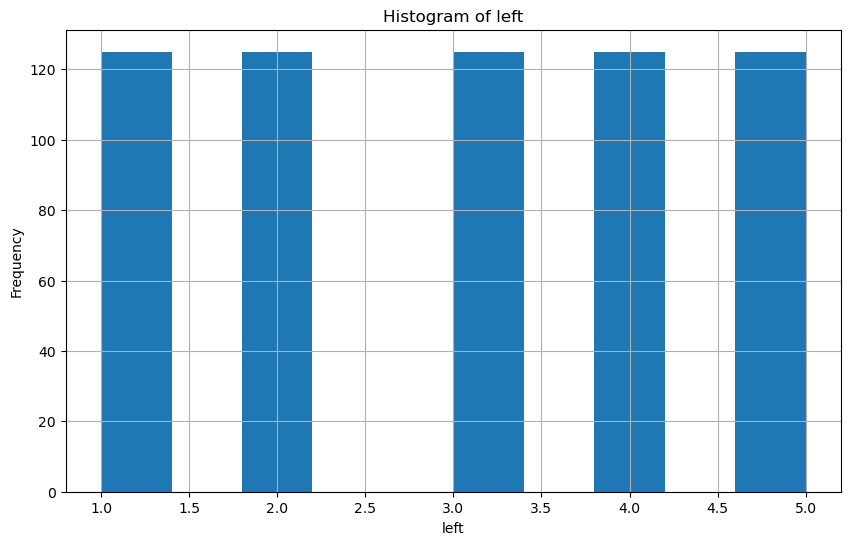

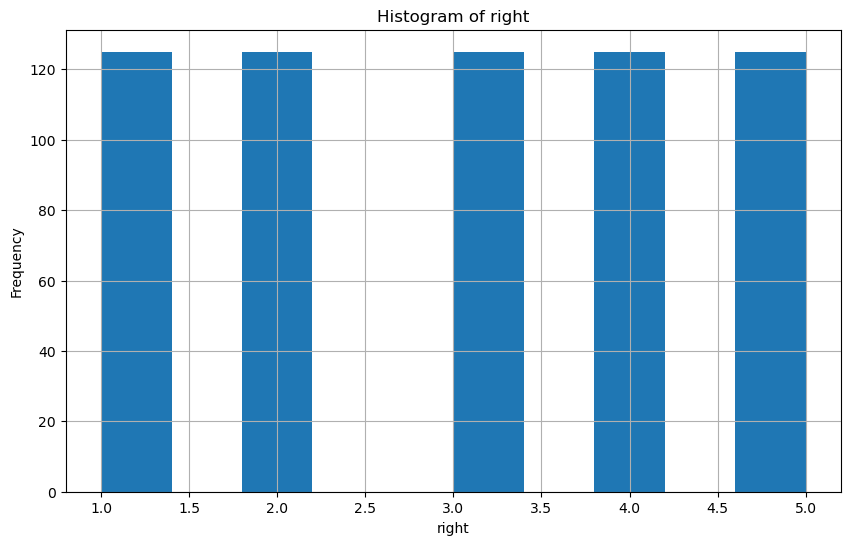

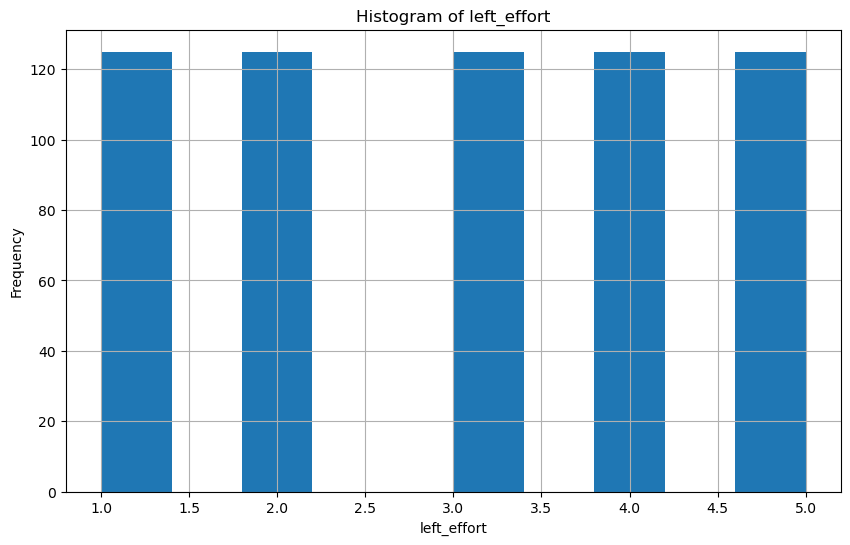

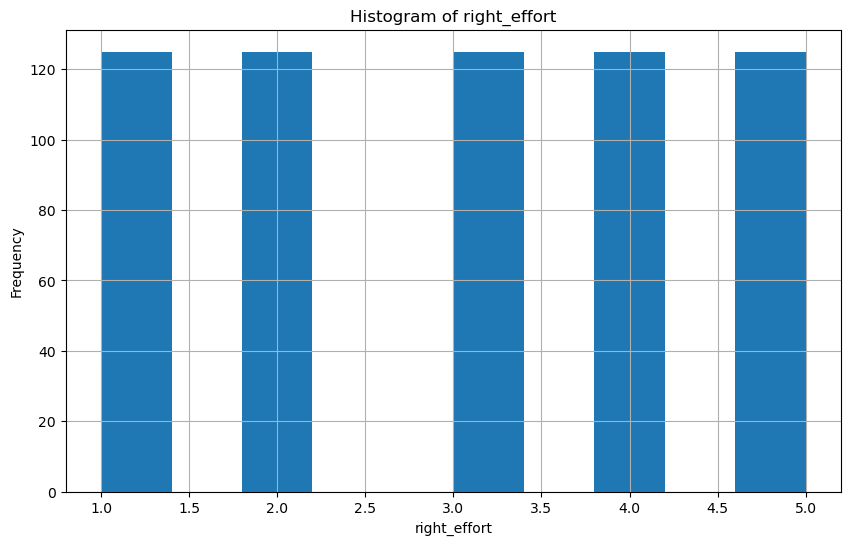

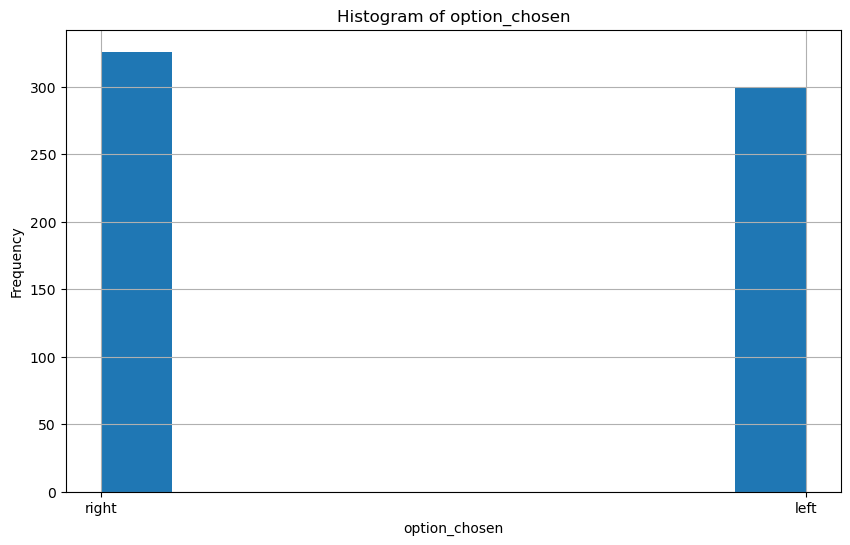

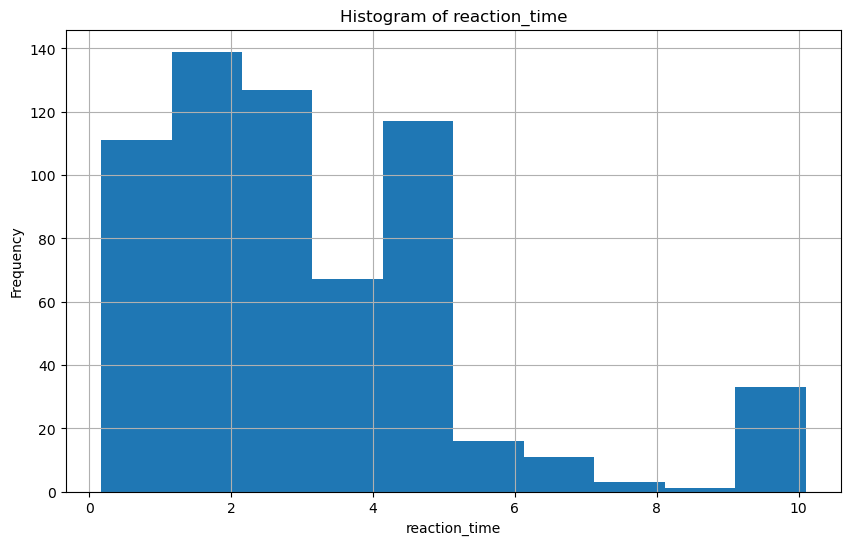

In [66]:
import matplotlib.pyplot as plt

for col in data.columns:
    plt.figure(figsize=(10, 6))
    plt.hist(data[col], bins=10)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.show()


Choices seem uniform, more right choices than left choices

Here is a plot that we see commonly in the decision making literature.

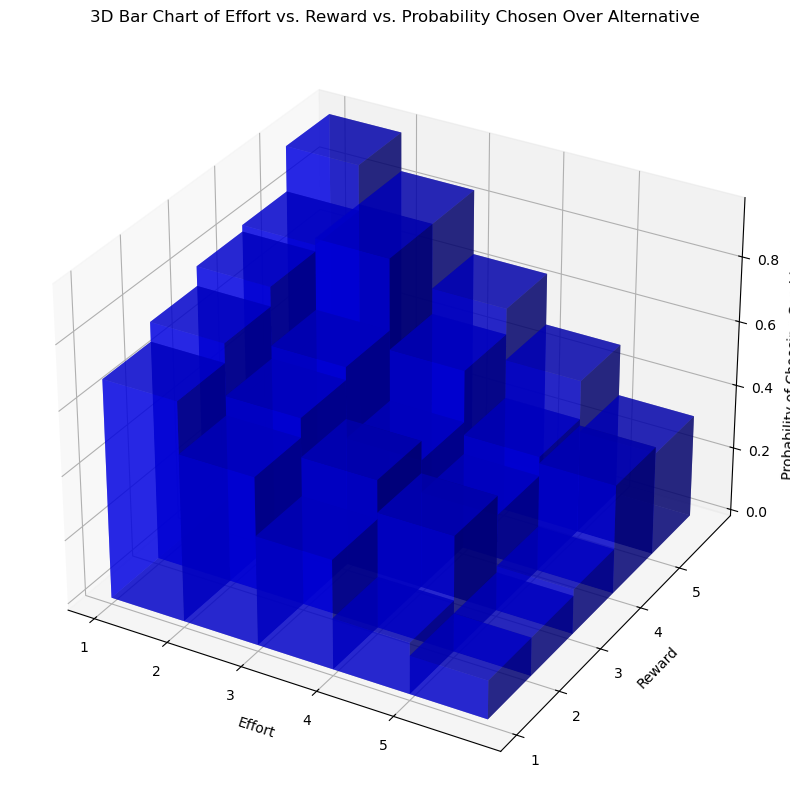

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Load the data
decision_data = pd.read_csv('decision_data.csv')

# Calculate counts for each effort-reward combination when chosen
chosen_counts = decision_data.apply(
    lambda row: (row['left_effort'], row['left']) if row['option_chosen'] == 'left' else (row['right_effort'], row['right']), axis=1
).value_counts().reset_index(name='chosen_count')
chosen_counts.columns = ['combination', 'chosen_count']

# Calculate total counts for each effort-reward combination regardless of choice
total_counts = decision_data.apply(
    lambda row: [(row['left_effort'], row['left']), (row['right_effort'], row['right'])], axis=1
).explode().value_counts().reset_index(name='total_count')
total_counts.columns = ['combination', 'total_count']

# Merge and calculate probability of being chosen over the alternative
probability_data = pd.merge(chosen_counts, total_counts, on='combination')
probability_data['probability'] = probability_data['chosen_count'] / probability_data['total_count']

# Extract effort and reward from combination tuples
probability_data[['effort', 'reward']] = pd.DataFrame(probability_data['combination'].tolist(), index=probability_data.index)

# Prepare data for 3D bar plot
x = probability_data['effort']
y = probability_data['reward']
z = np.zeros_like(x)
dx = dy = np.ones_like(x)
dz = probability_data['probability']

# Create a 3D bar plot with increased transparency
fig = plt.figure(figsize=(16, 10))
ax = fig.add_subplot(111, projection='3d')

ax.bar3d(x, y, z, dx, dy, dz, color='b', alpha=0.6)  # Increased transparency with alpha=0.6

ax.set_xlabel('Effort')
ax.set_ylabel('Reward')
ax.set_zlabel('Probability of Choosing Combination')
ax.set_title('3D Bar Chart of Effort vs. Reward vs. Probability Chosen Over Alternative')

# Set ticks for better readability
ax.set_xticks(np.arange(1, 6))
ax.set_yticks(np.arange(1, 6))

plt.show()

We can clearly see that as effort increases, the probability of an option being chosen goes down. Additionally, we see that as reward increases, the probability of selecting that option goes up. We do certainly have some noise - which is very normal in human experiments.

# Analysis of Decision Data
We can see from the previous plot that there are multiple effort and reward combinations where the individual is _indifferent_ to the two options (where probability of choosing the option is 1/2). In economics, psychology and neuroscience, a way to quantitatively identify this indifference point is via _logistic regression_.

Specifically, we assume that the individual chooses an option that maximizes a decision variable. In the following cells, we assume a relationship where $$Decision\;Variable = DV = \beta_1 Reward - \beta_2 \times  Effort$$ where $\beta_1$ and $\beta_2$ are learned parameters that reflect the cost of the effort relative to reward. Note that this is purely an assumption. This may not be the true relationship between effort and reward.

After assuming a decision variable structure, we fit a model where the probability of choosing an option is a logistic function of the differences of the decision variable. 

$$P(Choose\;Right) = \frac{1}{1 + e^{-DV_{right} + DV_{left}}}$$

The following model fits two parameters $\beta_1$ and $\beta_2$ using scikit-learn's logistic regression model.

In [40]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler

# Load the data
decision_data = pd.read_csv('decision_data.csv')

# Define chosen combination (Combination of reward and effort based on right/left choice stored as tuple)
decision_data['combination_chosen'] = decision_data.apply(
    lambda row: (row['left_effort'], row['left']) if row['option_chosen'] == 'left' else (row['right_effort'], row['right']), axis=1)

# Turns the option chosen (Right/Left) into 1/0
decision_data['choice_binary'] = decision_data['option_chosen'].apply(lambda x: 1 if x == 'right' else 0)

# Calculate differences for logistic regression
decision_data['reward_diff'] = decision_data['right'] - decision_data['left']
decision_data['effort_diff'] = decision_data['right_effort'] - decision_data['left_effort']

# Features and target
X = decision_data[['reward_diff', 'effort_diff']]
y = decision_data['choice_binary']

# Train and test split
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit logistic regression model
log_reg = LogisticRegression(fit_intercept=False, random_state=42)
log_reg.fit(X_train, y_train)

# Extract coefficients
coefficients = log_reg.coef_[0]
beta_1, beta_2 = coefficients
print(f'beta_1 = {beta_1}, beta_2 = {beta_2}')

beta_1 = 0.5099242768533472, beta_2 = -1.1349657255051842


Now, using the two parameters that we have learned, let's examine how the effort and reward amounts affect the decision probability.

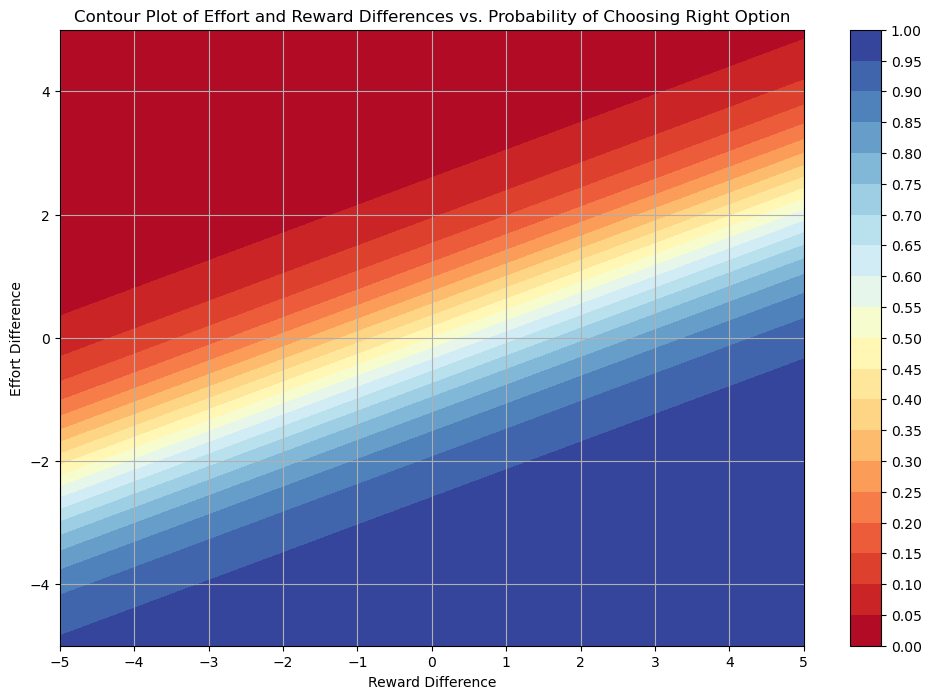

In [41]:
# Plot Effort Reward vs Probability Contour Plot

# Generate grid for plotting

effort_differences = np.linspace(-5, 5, 100)
reward_differences = np.linspace(-5, 5, 100)

effort_diff, reward_diff = np.meshgrid(effort_differences, reward_differences)
decision_variable = beta_1 * reward_diff + beta_2 * effort_diff
predicted_probabilities = 1 / (1 + np.exp(-decision_variable))

# Plot the contour plot
plt.figure(figsize=(12, 8))
levels = np.arange(0, 1.05, 0.05)

# Use the levels in contourf
contour = plt.contourf(reward_diff, effort_diff, predicted_probabilities, levels=levels, cmap='RdYlBu')
plt.grid(True)
# legend range (0, 1)

cbar = plt.colorbar(contour, ticks=levels)
cbar.ax.set_yticklabels(['{:.2f}'.format(i) for i in levels])
plt.xticks(np.arange(int(reward_diff.min()), int(reward_diff.max()) + 1, 1))
plt.xlabel('Reward Difference')
plt.ylabel('Effort Difference')
plt.title('Contour Plot of Effort and Reward Differences vs. Probability of Choosing Right Option')
plt.show()

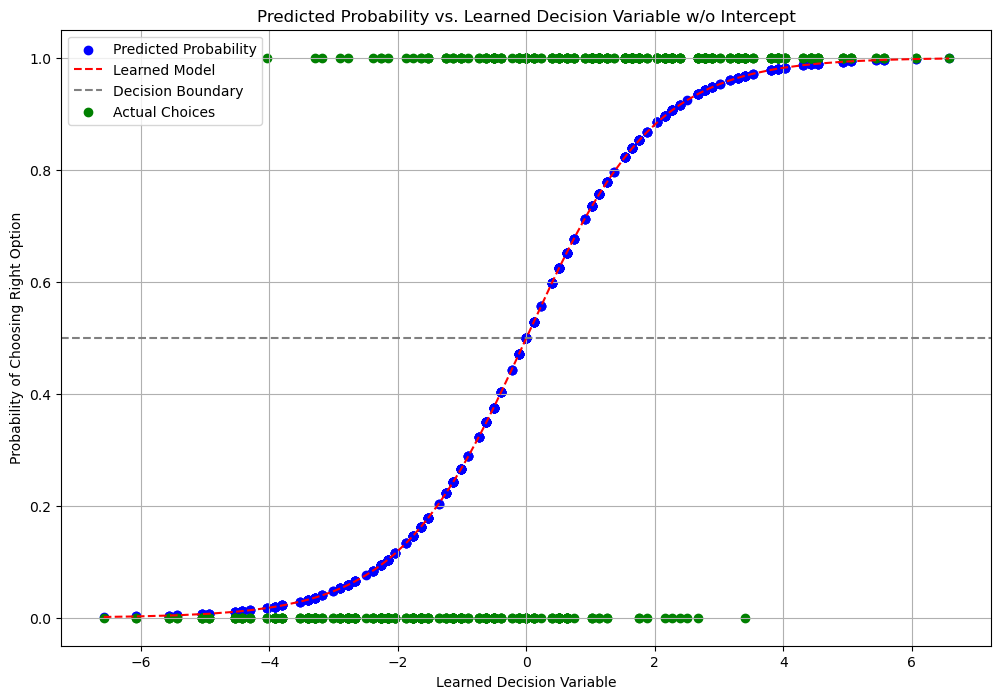

In [42]:
# Plot Predicted Probability vs. Learned Decision Variable
decision_data["learned_decision_variable"] = beta_1 * decision_data["reward_diff"] + beta_2 * decision_data["effort_diff"]
decision_data["predicted_probability"] = 1 / (1 + np.exp(-decision_data["learned_decision_variable"]))

# Plot data points with predicted probabilities and sigmoid function
# Sort the data by the learned decision variable
decision_data = decision_data.sort_values('learned_decision_variable')
plt.figure(figsize=(12, 8))
plt.scatter(decision_data["learned_decision_variable"], decision_data["predicted_probability"], color='b', label='Predicted Probability')
plt.plot(decision_data["learned_decision_variable"], decision_data["predicted_probability"], color='r', linestyle='dashed', label='Learned Model')
plt.axhline(y=0.5, color='gray', linestyle='dashed', label='Decision Boundary')
# Plot actual data points
plt.scatter(decision_data["learned_decision_variable"], decision_data["choice_binary"], color='g', label='Actual Choices')
plt.xlabel('Learned Decision Variable')
plt.ylabel('Probability of Choosing Right Option')
plt.title('Predicted Probability vs. Learned Decision Variable w/o Intercept')
plt.legend()
plt.grid(True)
plt.show()


From the above plot we can see that seems to be a clear effort reward tradeoff. To remain indifferent, how much do we need to increase the reward difference to get a unit increase in effort?

Answer: about 2 (slope?)

Now, let's also visualize the model with respect to the learned decision variables.

Great! Now let's have you get some practice. Fit a similar logistic regression model, but this time, assume that

$P(Choose\;Right) = \frac{1}{1 + e^{\beta_0 -DV_{right} + DV_{left}}}$  

Note that the decision variable is the same as last time. The only change is that we have an additional intercept term, $\beta_0$ to fit. Use the same set of code from last time but remember to rename variables and  the axes. Look at the [sklearn documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) to see how to do this.


In [44]:
# TODO: Learn the model and beta coefficients using the data

import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler

X = decision_data[['reward_diff', 'effort_diff']]
y = decision_data['choice_binary']

# Train and test split
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit logistic regression model
log_reg = LogisticRegression(fit_intercept=True, random_state=42)
log_reg.fit(X_train, y_train)

# Extract coefficients
coefficients = log_reg.coef_[0]
beta_0 = log_reg.intercept_[0]
beta_1, beta_2 = coefficients
print(f'beta_0 = {beta_0} beta_1 = {beta_1}, beta_2 = {beta_2}')

beta_0 = 0.2060545121957602 beta_1 = 0.5321649387156804, beta_2 = -1.093553508508401


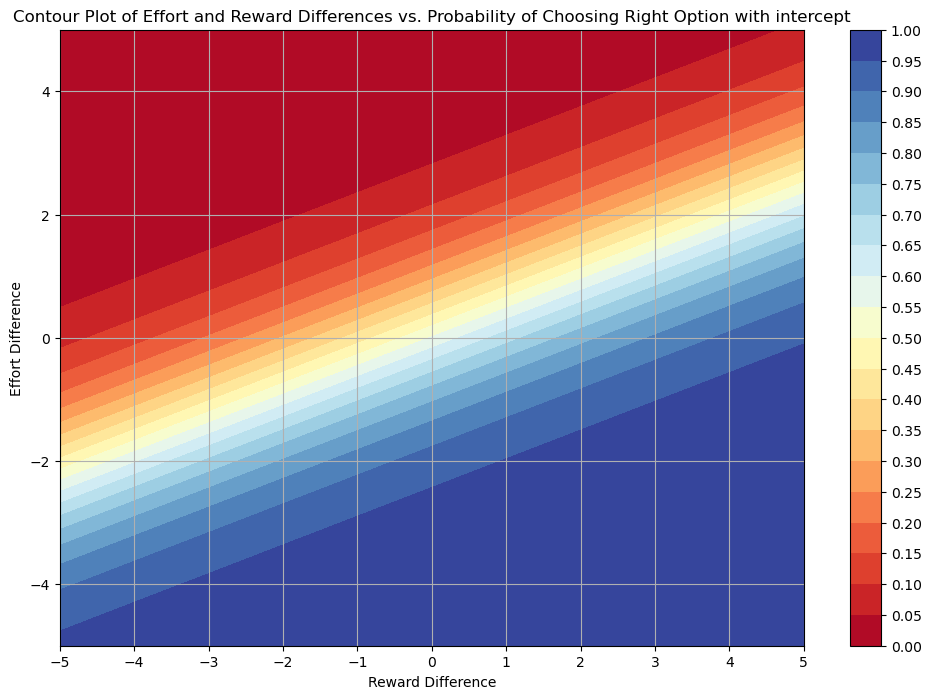

In [53]:
# TODO: Plot the contour plot of effort and reward differences vs. probability of choosing the right option

# Plot Effort Reward vs Probability Contour Plot

# Generate grid for plotting

effort_differences = np.linspace(-5, 5, 100)
reward_differences = np.linspace(-5, 5, 100)

effort_diff, reward_diff = np.meshgrid(effort_differences, reward_differences)
decision_variable = beta_0 + beta_1 * reward_diff + beta_2 * effort_diff
predicted_probabilities = 1 / (1 + np.exp(-decision_variable))

# Plot the contour plot
plt.figure(figsize=(12, 8))
levels = np.arange(0, 1.05, 0.05)

# Use the levels in contourf
contour = plt.contourf(reward_diff, effort_diff, predicted_probabilities, levels=levels, cmap='RdYlBu')
plt.grid(True)
# legend range (0, 1)

cbar = plt.colorbar(contour, ticks=levels)
cbar.ax.set_yticklabels(['{:.2f}'.format(i) for i in levels])
plt.xticks(np.arange(int(reward_diff.min()), int(reward_diff.max()) + 1, 1))
plt.xlabel('Reward Difference')
plt.ylabel('Effort Difference')
plt.title('Contour Plot of Effort and Reward Differences vs. Probability of Choosing Right Option with intercept')
plt.show()

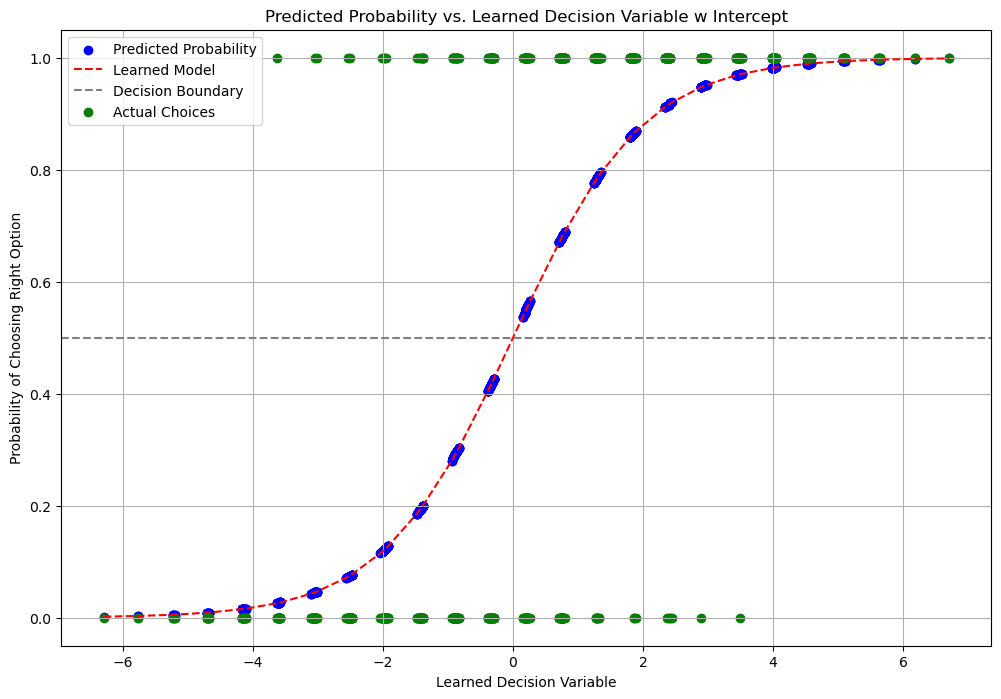

In [46]:
# TODO: Plot the predicted probability vs. learned decision variable with actual choices

# Plot Predicted Probability vs. Learned Decision Variable
decision_data["learned_decision_variable_intercept"] = beta_0 + beta_1 * decision_data["reward_diff"] + beta_2 * decision_data["effort_diff"]
decision_data["predicted_probability_intercept"] = 1 / (1 + np.exp(-decision_data["learned_decision_variable_intercept"]))

# Plot data points with predicted probabilities and sigmoid function
# Sort the data by the learned decision variable
decision_data = decision_data.sort_values('learned_decision_variable_intercept')
plt.figure(figsize=(12, 8))
plt.scatter(decision_data["learned_decision_variable_intercept"], decision_data["predicted_probability_intercept"], color='b', label='Predicted Probability')
plt.plot(decision_data["learned_decision_variable_intercept"], decision_data["predicted_probability_intercept"], color='r', linestyle='dashed', label='Learned Model')
plt.axhline(y=0.5, color='gray', linestyle='dashed', label='Decision Boundary')
# Plot actual data points
plt.scatter(decision_data["learned_decision_variable_intercept"], decision_data["choice_binary"], color='g', label='Actual Choices')
plt.xlabel('Learned Decision Variable')
plt.ylabel('Probability of Choosing Right Option')
plt.title('Predicted Probability vs. Learned Decision Variable w Intercept')
plt.legend()
plt.grid(True)
plt.show()


Good work! We now have two models that have fit the data. George Box, a famous statistician once said, "All models are wrong; some are useful." How do we pick the right one?

This is where _model selection_ comes into play. We need to choose the better model according to a validation set. (Note that this is **not** the test set). We can only use the test set once otherwise it no longer stays a test set.

Specifically, let's use the Bayesian Information Criterion to choose the better model.

$$BIC = k ln (n) - 2 ln(L)$$ 

Here, $k$ is the number of parameters we learn for the model, $n$ is the number of observation in the validation set and $L$ is the likelihood of the model.

For both models, split the training set into a training set and validation set, fit the model on the training set and calculate the BIC on the validation set for each model. Note that lower is better! Use the BIC function I have provided

In [51]:
from sklearn.metrics import log_loss

def BIC(k, data, labels):
    n = len(data)
    log_likelihood = -log_loss(labels, log_reg.predict_proba(data))
    return k * np.log(n) - 2 * log_likelihood

In [54]:
# TODO: Calculate BIC scores for both models

X_train_2, X_val, y_train_2, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Fit for first model
log_reg = LogisticRegression(fit_intercept=False, random_state=42)
log_reg.fit(X_train_2, y_train_2)

#Calculate BIC for the first model
BIC_without_intercept = BIC(2, X_val, y_val)
print(f"BIC Without Intercept {BIC_without_intercept}")

# Fit for the second model
log_reg = LogisticRegression(fit_intercept=True, random_state=42)
log_reg.fit(X_train_2, y_train_2)

# Calculate BIC for the second model
BIC_with_intercept = BIC(3, X_val, y_val)
print(f"BIC with Intercept {BIC_with_intercept}")


BIC Without Intercept 10.103668869676158
BIC with Intercept 14.705060744479665


Which is the better model? And why?

Answer: The LogReg without intercept because it has a lower BIC score (10.1 vs 14.7)

Now, retrain the model on the training set and validation set combined and calculate the AUC-ROC score on the test set which evaluates the ability of the model to distinguish between picking right or left. Refer to [sklearn.metrics.roc_auc_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html#sklearn.metrics.roc_auc_score) to see how to do this.

In [ ]:
from sklearn.metrics import roc_auc_score
# TODO: Calculate AUC test score for the better model.

# Fit for first model
log_reg = LogisticRegression(fit_intercept=False, random_state=42)
log_reg.fit(X_train, y_train)

AUC_test_score_without_intercept = roc_auc_score(y_test, log_reg.predict_proba(X_test)[:, 1])
print(AUC_test_score_without_intercept)

# Fit for second model
log_reg = LogisticRegression(fit_intercept=True, random_state=42)
log_reg.fit(X_train, y_train)

AUC_test_score_with_intercept = roc_auc_score(y_test, log_reg.predict_proba(X_test)[:, 1])
print(AUC_test_score_with_intercept)

0.91
0.91


# Software Engineering

Well done, you are almost at the end. 

Though our research answers important neuroscience, economics and psychology research questions, we rely heavily on software engineering to both implement our tasks and analyze our data.

Learning how to test, document and refactor code is critical to minimize catastrophic careless errors. In general, a software engineering rule of thumb is to spend 15% of your programming time refactoring code.

## Automated Tests

Credit: Kyle Johnsen

One way we do this is with automated tests. Write tests (using assert statements) for the following function. In real software (using pytest), we would put the test function in a test file, would be run automatically by simply calling pytest from the command line.

In [67]:
import numpy as np
# TODO: Implement automated test
def axial_distance(source_xyz: list, target_xyz: list, dir_xyz: list) -> float:
    """Calculates the axial distance between two points in a given direction.
    Args:
        source_xyz (list): The source point in cartesian coordinates.
        target_xyz (list): The target point in cartesian coordinates.
        dir_xyz (list): The direction in which to calculate the distance.
    Returns:
        float: The axial distance between the source and target points.
    """
    dir_normalized = np.divide(dir_xyz, np.linalg.norm(dir_xyz))
    source_to_target = np.subtract(target_xyz, source_xyz)
    axial_distance = np.dot(source_to_target, dir_normalized)
    return axial_distance

def test_axial_distance():
    assert axial_distance([0, 0, 0], [1, 0, 0], [1, 0, 0]) == 1 # Increase in same X direction
    # TODO: write more tests and explain why that test case was chosen
    assert axial_distance([1, 0, 0], [1, 0, 0], [0, 0, 0]) == 0 # 0 Vector for direction does not make sense, so this tests the edge case
    assert axial_distance([1, 0, 0], [1, 0, 0], [1, 0, 0]) == 0 # No Change in Direction (X direction)
    assert axial_distance([1, 0, 0], [15, 0, 0], [0, 1, 0]) == 0 # Change in direction X, no change in Y
    assert axial_distance([1, 0, 0], [5, 0, 0], [1, 0, 0]) == 4 # Change in Direction (X direction)
    assert axial_distance([5, 0, 0], [1, 0, 0], [1, 0, 0]) == -4 # Change in Opposite Direction (X direction)
    assert axial_distance([0, 1, 0], [0, 1, 0], [0, 1, 0]) == 0 # No Change in Direction (Y direction)
    assert axial_distance([0, 0, 1], [1, 0, 1], [0, 0, 1]) == 0 # No Change in Direction (Z direction)
    
test_axial_distance()

/var/folders/j1/cxdv4vmj4dd3_qz33tpybty80000gn/T/ipykernel_3491/2060369073.py:12: RuntimeWarning: invalid value encountered in divide
  dir_normalized = np.divide(dir_xyz, np.linalg.norm(dir_xyz))


AssertionError: 

## Refactoring
Please refactor your entire code for this notebook.[Here](https://en.wikipedia.org/wiki/Zen_of_Python) is some inspiration for that. Yes, that may seem like a daunting task but take a break and come back to it. Refactoring allows you to refine your work to make it more intelligible and understandable for others (and yourself). Research never happens in a vacuum and it is important to not silo yourself off because of bad code.

Other resources are below.

https://docs.python-guide.org/writing/style/

https://testdriven.io/blog/clean-code-python/

Great job! Now, save your work and send an email to me (vivekanand@gatech.edu) with a link to your completed colab notebook.